<a href="https://colab.research.google.com/github/hackathon-cortex/Adaptive-pathing-/blob/main/risk_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
np.random.seed(42)

N = 5000

(0, 1, N)
distance = np.random.uniform(2, 50, N)
relative_velocity = np.random.uniform(-10, 10, N)
uncertainty = np.random.uniform(0, 1, N)
occupancy = np.random.uniform(0, 1, N)
behavior = np.random.uniform
# Time To Collision
ttc = np.where(
    relative_velocity < 0,
    distance / (-relative_velocity + 0.01),
    20
)

ttc = np.clip(ttc, 0, 20)

data = pd.DataFrame({
    "distance": distance,
    "relative_velocity": relative_velocity,
    "ttc": ttc,
    "uncertainty": uncertainty,
    "occupancy": occupancy,
    "behavior": behavior
})

data.head()

,distance,relative_velocity,ttc,uncertainty,occupancy,behavior
0,19.977926,-2.127290,9.347318,0.373641,0.499670,0.729998
1,47.634287,-0.531287,20.000000,0.332912,0.746747,0.184512
2,37.135709,7.090948,20.000000,0.176154,0.562667,0.346640
3,30.735607,-3.199912,9.575217,0.607267,0.083303,0.663281
4,9.488895,7.392994,20.000000,0.476624,0.185580,0.482089


In [ ]:
def risk_level(score):
    if score < 0.33:
        return 0
    elif score < 0.66:
        return 1
    else:
        return 2

data["risk"] = data["risk_score"].apply(risk_level)

data.head()

KeyError: 'risk_score'

In [ ]:
# Calculate risk score

risk_score = (
    0.35 * (1 / (data["distance"] + 1)) +
    0.30 * (1 / (data["ttc"] + 1)) +
    0.15 * data["uncertainty"] +
    0.10 * data["occupancy"] +
    0.10 * data["behavior"]
)

# Normalize risk score between 0 and 1
risk_score = (
    (risk_score - risk_score.min()) /
    (risk_score.max() - risk_score.min())
)

# Add risk score to dataset
data["risk_score"] = risk_score

print("Risk score created successfully!")

data.head()

Risk score created successfully!


,distance,relative_velocity,ttc,uncertainty,occupancy,behavior,risk_score
0,19.977926,-2.127290,9.347318,0.373641,0.499670,0.729998,0.322490
1,47.634287,-0.531287,20.000000,0.332912,0.746747,0.184512,0.220482
2,37.135709,7.090948,20.000000,0.176154,0.562667,0.346640,0.180239
3,30.735607,-3.199912,9.575217,0.607267,0.083303,0.663281,0.289341
4,9.488895,7.392994,20.000000,0.476624,0.185580,0.482089,0.256726


In [ ]:
print(data.columns.tolist())

['distance', 'relative_velocity', 'ttc', 'uncertainty', 'occupancy', 'behavior', 'risk_score']


In [ ]:
def risk_level(score):
    if score < 0.33:
        return 0
    elif score < 0.66:
        return 1
    else:
        return 2

data["risk"] = data["risk_score"].apply(risk_level)

data.head()

,distance,relative_velocity,ttc,uncertainty,occupancy,behavior,risk_score,risk
0,19.977926,-2.127290,9.347318,0.373641,0.499670,0.729998,0.322490,0
1,47.634287,-0.531287,20.000000,0.332912,0.746747,0.184512,0.220482,0
2,37.135709,7.090948,20.000000,0.176154,0.562667,0.346640,0.180239,0
3,30.735607,-3.199912,9.575217,0.607267,0.083303,0.663281,0.289341,0
4,9.488895,7.392994,20.000000,0.476624,0.185580,0.482089,0.256726,0


In [ ]:
print("Risk Class Distribution:")
print(data["risk"].value_counts())

print("\nRisk Labels:")
print("0 = LOW")
print("1 = MEDIUM")
print("2 = HIGH")

Risk Class Distribution:
risk
0    2528
1    2328
2     144
Name: count, dtype: int64

Risk Labels:
0 = LOW
1 = MEDIUM
2 = HIGH


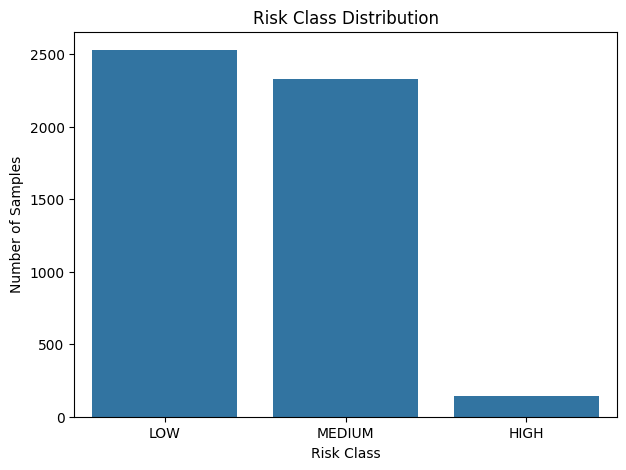

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(x="risk", data=data)

plt.title("Risk Class Distribution")
plt.xlabel("Risk Class")
plt.ylabel("Number of Samples")
plt.xticks(
    [0, 1, 2],
    ["LOW", "MEDIUM", "HIGH"]
)

plt.show()

In [ ]:
X = data[
    [
        "distance",
        "relative_velocity",
        "ttc",
        "uncertainty",
        "occupancy",
        "behavior"
    ]
]

y = data["risk"]

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
    distance  relative_velocity        ttc  uncertainty  occupancy  behavior
0  19.977926          -2.127290   9.347318     0.373641   0.499670  0.729998
1  47.634287          -0.531287  20.000000     0.332912   0.746747  0.184512
2  37.135709           7.090948  20.000000     0.176154   0.562667  0.346640
3  30.735607          -3.199912   9.575217     0.607267   0.083303  0.663281
4   9.488895           7.392994  20.000000     0.476624   0.185580  0.482089

Target:
0    0
1    0
2    0
3    0
4    0
Name: risk, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4000
Testing samples: 1000


In [ ]:
from sklearn.ensemble import RandomForestClassifier

risk_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    class_weight="balanced"
)

risk_model.fit(X_train, y_train)

print("Risk Predictor Model trained successfully!")


Risk Predictor Model trained successfully!


In [ ]:
y_pred = risk_model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!

First 20 predictions:
[0 1 0 0 0 1 1 0 0 1 1 0 1 0 0 0 0 1 1 0]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 94.40%


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["LOW", "MEDIUM", "HIGH"]
    )
)

              precision    recall  f1-score   support

         LOW       0.96      0.95      0.95       506
      MEDIUM       0.93      0.95      0.94       465
        HIGH       0.89      0.83      0.86        29

    accuracy                           0.94      1000
   macro avg       0.93      0.91      0.92      1000
weighted avg       0.94      0.94      0.94      1000



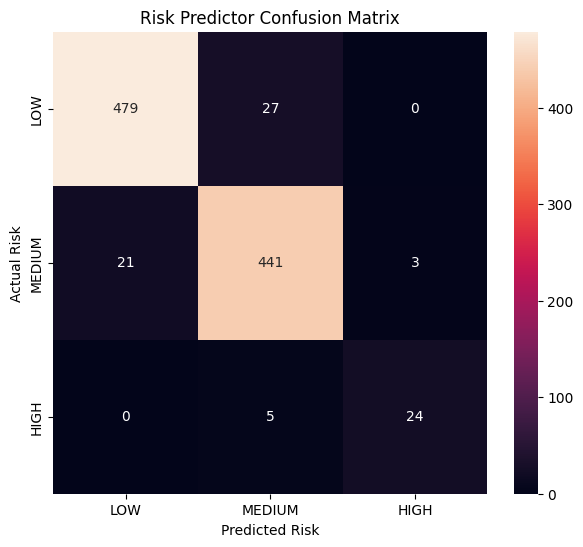

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["LOW", "MEDIUM", "HIGH"],
    yticklabels=["LOW", "MEDIUM", "HIGH"]
)

plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.title("Risk Predictor Confusion Matrix")

plt.show()

In [ ]:
# Get probability predictions
risk_probabilities = risk_model.predict_proba(X_test)

print("Probability shape:", risk_probabilities.shape)
print("\nFirst 5 probability predictions:")
print(risk_probabilities[:5])

Probability shape: (1000, 3)

First 5 probability predictions:
[[0.92521304 0.07478696 0.        ]
 [0.015      0.77       0.215     ]
 [0.9919471  0.0080529  0.        ]
 [0.81239768 0.18760232 0.        ]
 [0.99313361 0.00686639 0.        ]]


In [ ]:
# HIGH risk probability as risk score
risk_scores = risk_probabilities[:, 2]

print("First 20 Risk Scores:")
print(risk_scores[:20])

First 20 Risk Scores:
[0.    0.215 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.09  0.    0.   ]


In [ ]:
risk_labels = {
    0: "LOW",
    1: "MEDIUM",
    2: "HIGH"
}

predicted_classes = risk_model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predicted_classes,
    "Low_Probability": risk_probabilities[:, 0],
    "Medium_Probability": risk_probabilities[:, 1],
    "High_Probability": risk_probabilities[:, 2],
    "Risk_Score": risk_scores
})

results["Risk_Level"] = results["Predicted"].map(risk_labels)

results.head(10)

,Actual,Predicted,Low_Probability,Medium_Probability,High_Probability,Risk_Score,Risk_Level
0,0,0,0.925213,0.074787,0.000,0.000,LOW
1,1,1,0.015000,0.770000,0.215,0.215,MEDIUM
2,0,0,0.991947,0.008053,0.000,0.000,LOW
3,0,0,0.812398,0.187602,0.000,0.000,LOW
4,0,0,0.993134,0.006866,0.000,0.000,LOW
5,1,1,0.001221,0.998779,0.000,0.000,MEDIUM
6,1,1,0.040128,0.959872,0.000,0.000,MEDIUM
7,0,0,0.764939,0.235061,0.000,0.000,LOW
8,0,0,0.799161,0.200839,0.000,0.000,LOW
9,1,1,0.040886,0.959114,0.000,0.000,MEDIUM


In [ ]:
scenario = pd.DataFrame([{
    "distance": 8.5,
    "relative_velocity": -3.2,
    "ttc": 2.65,
    "uncertainty": 0.32,
    "occupancy": 0.70,
    "behavior": 0.80
}])

prediction = risk_model.predict(scenario)[0]
probability = risk_model.predict_proba(scenario)[0]

risk_score = probability[2]

print("===== RISK PREDICTION =====")
print(f"Risk Score : {risk_score:.3f}")
print(f"LOW        : {probability[0]:.3f}")
print(f"MEDIUM     : {probability[1]:.3f}")
print(f"HIGH       : {probability[2]:.3f}")
print(f"Risk Level : {risk_labels[prediction]}")

===== RISK PREDICTION =====
Risk Score : 0.005
LOW        : 0.061
MEDIUM     : 0.934
HIGH       : 0.005
Risk Level : MEDIUM


In [ ]:
import joblib

joblib.dump(risk_model, "risk_predictor.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
loaded_model = joblib.load("risk_predictor.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
def predict_risk(
    distance,
    relative_velocity,
    ttc,
    uncertainty,
    occupancy,
    behavior
):

    input_data = pd.DataFrame([{
        "distance": distance,
        "relative_velocity": relative_velocity,
        "ttc": ttc,
        "uncertainty": uncertainty,
        "occupancy": occupancy,
        "behavior": behavior
    }])

    # Prediction
    prediction = loaded_model.predict(input_data)[0]

    # Probabilities
    probabilities = loaded_model.predict_proba(input_data)[0]

    # HIGH probability = risk score
    risk_score = probabilities[2]

    labels = {
        0: "LOW",
        1: "MEDIUM",
        2: "HIGH"
    }

    return {
        "risk_score": float(risk_score),
        "risk_level": labels[prediction],
        "low_probability": float(probabilities[0]),
        "medium_probability": float(probabilities[1]),
        "high_probability": float(probabilities[2])
    }

In [ ]:
result = predict_risk(
    distance=8.5,
    relative_velocity=-3.2,
    ttc=2.65,
    uncertainty=0.32,
    occupancy=0.70,
    behavior=0.80
)

print(result)

{'risk_score': 0.005, 'risk_level': 'MEDIUM', 'low_probability': 0.06058156958231879, 'medium_probability': 0.9344184304176812, 'high_probability': 0.005}


In [ ]:
scenarios = {

    "Safe Road": {
        "distance": 40,
        "relative_velocity": 0,
        "ttc": 20,
        "uncertainty": 0.05,
        "occupancy": 0.10,
        "behavior": 0.10
    },

    "Moderate Risk": {
        "distance": 15,
        "relative_velocity": -2,
        "ttc": 7.5,
        "uncertainty": 0.30,
        "occupancy": 0.40,
        "behavior": 0.40
    },

    "Dangerous Situation": {
        "distance": 5,
        "relative_velocity": -5,
        "ttc": 1,
        "uncertainty": 0.80,
        "occupancy": 0.90,
        "behavior": 0.90
    }
}

for name, values in scenarios.items():

    result = predict_risk(**values)

    print("\n==============================")
    print(name)
    print("==============================")
    print(f"Risk Score : {result['risk_score']:.3f}")
    print(f"Risk Level : {result['risk_level']}")


Safe Road
Risk Score : 0.000
Risk Level : LOW

Moderate Risk
Risk Score : 0.000
Risk Level : LOW

Dangerous Situation
Risk Score : 0.854
Risk Level : HIGH


In [ ]:
import math
import numpy as np

class HumanLikeRiskEngine:
    """
    Explainable Risk Engine for Autonomous Vehicle.
    Risk score: 0.0 - 1.0
    """

    def __init__(self):
        self.weights = {
            "collision": 0.30,
            "ttc": 0.20,
            "clearance": 0.15,
            "occupancy": 0.10,
            "behavior": 0.10,
            "uncertainty": 0.10,
            "context": 0.05
        }

    def clamp(self, value, low=0.0, high=1.0):
        return max(low, min(high, float(value)))

    def collision_risk(self, distance, relative_speed):
        if distance <= 0:
            return 1.0

        # Risk increases rapidly when obstacle gets closer
        distance_risk = math.exp(-distance / 12.0)

        # Relative speed contribution
        speed_risk = self.clamp(abs(relative_speed) / 12.0)

        return self.clamp(
            0.65 * distance_risk +
            0.35 * speed_risk
        )

    def ttc_risk(self, distance, relative_speed):
        if relative_speed <= 0:
            return 0.05

        ttc = distance / relative_speed

        if ttc <= 1:
            return 1.0
        elif ttc <= 2:
            return 0.90
        elif ttc <= 3:
            return 0.70
        elif ttc <= 5:
            return 0.45
        elif ttc <= 8:
            return 0.20
        else:
            return 0.05

    def clearance_risk(self, clearance):
        if clearance <= 1:
            return 1.0
        elif clearance <= 2:
            return 0.85
        elif clearance <= 3:
            return 0.60
        elif clearance <= 5:
            return 0.30
        elif clearance <= 8:
            return 0.10
        else:
            return 0.02

    def occupancy_risk(self, distance, obstacle_size=1.0):
        proximity = math.exp(-distance / 15.0)
        size_factor = self.clamp(obstacle_size / 3.0)

        return self.clamp(
            0.75 * proximity +
            0.25 * size_factor
        )

    def behavior_risk(self, obstacle_type):
        obstacle_type = str(obstacle_type).lower()

        risk_map = {
            "pedestrian": 0.85,
            "cattle": 0.90,
            "animal": 0.85,
            "bicycle": 0.70,
            "motorcycle": 0.60,
            "vehicle": 0.45,
            "truck": 0.55,
            "static_object": 0.25,
            "cone": 0.15
        }

        return risk_map.get(obstacle_type, 0.40)

    def uncertainty_risk(self, uncertainty):
        return self.clamp(uncertainty)

    def context_risk(self, road_context):
        context_map = {
            "highway": 0.25,
            "urban": 0.45,
            "intersection": 0.70,
            "village": 0.55,
            "market": 0.80,
            "cattle_crossing": 0.85
        }

        return context_map.get(
            str(road_context).lower(), 0.40
        )

    def calculate(
        self,
        distance,
        relative_speed,
        clearance,
        obstacle_type="vehicle",
        uncertainty=0.20,
        road_context="urban",
        obstacle_size=1.0
    ):

        components = {}

        components["collision"] = self.collision_risk(
            distance,
            relative_speed
        )

        components["ttc"] = self.ttc_risk(
            distance,
            relative_speed
        )

        components["clearance"] = self.clearance_risk(
            clearance
        )

        components["occupancy"] = self.occupancy_risk(
            distance,
            obstacle_size
        )

        components["behavior"] = self.behavior_risk(
            obstacle_type
        )

        components["uncertainty"] = self.uncertainty_risk(
            uncertainty
        )

        components["context"] = self.context_risk(
            road_context
        )

        # Weighted risk
        risk_score = sum(
            components[key] * self.weights[key]
            for key in self.weights
        )

        # Human-like conservative response
        if uncertainty > 0.70:
            risk_score += 0.05

        if obstacle_type.lower() in ["pedestrian", "cattle", "animal"]:
            risk_score += 0.05

        risk_score = self.clamp(risk_score)

        # Risk classification
        if risk_score < 0.25:
            level = "LOW"
        elif risk_score < 0.50:
            level = "MODERATE"
        elif risk_score < 0.75:
            level = "HIGH"
        else:
            level = "CRITICAL"

        return {
            "risk_score": round(risk_score, 3),
            "risk_level": level,
            "components": {
                k: round(v, 3)
                for k, v in components.items()
            }
        }


risk_engine = HumanLikeRiskEngine()

print("Human-Like Risk Engine v2 loaded successfully.")

Human-Like Risk Engine v2 loaded successfully.


In [ ]:
scenarios = {
    "Safe Road": {
        "distance": 40,
        "relative_speed": 0.5,
        "clearance": 8,
        "obstacle_type": "vehicle",
        "uncertainty": 0.10,
        "road_context": "highway"
    },

    "Moderate Risk": {
        "distance": 15,
        "relative_speed": 3,
        "clearance": 4,
        "obstacle_type": "vehicle",
        "uncertainty": 0.30,
        "road_context": "urban"
    },

    "Dangerous Situation": {
        "distance": 6,
        "relative_speed": 7,
        "clearance": 1.5,
        "obstacle_type": "cattle",
        "uncertainty": 0.65,
        "road_context": "cattle_crossing"
    }
}

for name, data in scenarios.items():

    result = risk_engine.calculate(**data)

    print("\n" + "=" * 45)
    print(name)
    print("=" * 45)

    print(f"Risk Score : {result['risk_score']:.3f}")
    print(f"Risk Level : {result['risk_level']}")

    print("\nRisk Components:")
    for component, value in result["components"].items():
        print(f"  {component:<15}: {value:.3f}")


Safe Road
Risk Score : 0.117
Risk Level : LOW

Risk Components:
  collision      : 0.038
  ttc            : 0.050
  clearance      : 0.100
  occupancy      : 0.135
  behavior       : 0.450
  uncertainty    : 0.100
  context        : 0.250

Moderate Risk
Risk Score : 0.351
Risk Level : MODERATE

Risk Components:
  collision      : 0.274
  ttc            : 0.450
  clearance      : 0.300
  occupancy      : 0.359
  behavior       : 0.450
  uncertainty    : 0.300
  context        : 0.450

Dangerous Situation
Risk Score : 0.813
Risk Level : CRITICAL

Risk Components:
  collision      : 0.598
  ttc            : 1.000
  clearance      : 0.850
  occupancy      : 0.586
  behavior       : 0.900
  uncertainty    : 0.650
  context        : 0.850

Safe Road
Risk Score : 0.117
Risk Level : LOW

Risk Components:
  collision      : 0.038
  ttc            : 0.050
  clearance      : 0.100
  occupancy      : 0.135
  behavior       : 0.450
  uncertainty    : 0.100
  context        : 0.250

Moderate Risk
R

In [ ]:
import numpy as np
import math

def predict_future_risk(
    distance,
    ego_speed,
    obstacle_speed,
    clearance,
    obstacle_type="vehicle",
    uncertainty=0.20,
    road_context="urban",
    horizon=5,
    dt=1.0
):
    """
    Predict risk over the next few seconds.
    """

    results = []

    relative_speed = ego_speed - obstacle_speed

    for t in np.arange(0, horizon + dt, dt):

        # Future distance
        future_distance = distance - (relative_speed * t)

        # Prevent negative distance
        future_distance = max(0.1, future_distance)

        # Uncertainty grows with prediction horizon
        future_uncertainty = min(
            1.0,
            uncertainty + (0.05 * t)
        )

        # Clearance decreases as obstacle gets closer
        future_clearance = max(
            0.3,
            clearance - (max(relative_speed, 0) * 0.15 * t)
        )

        risk = risk_engine.calculate(
            distance=future_distance,
            relative_speed=relative_speed,
            clearance=future_clearance,
            obstacle_type=obstacle_type,
            uncertainty=future_uncertainty,
            road_context=road_context
        )

        results.append({
            "time": round(float(t), 1),
            "distance": round(future_distance, 2),
            "clearance": round(future_clearance, 2),
            "uncertainty": round(future_uncertainty, 2),
            "risk_score": risk["risk_score"],
            "risk_level": risk["risk_level"]
        })

    return results

In [ ]:
future_risk = predict_future_risk(
    distance=20,
    ego_speed=8.0,
    obstacle_speed=2.0,
    clearance=5.0,
    obstacle_type="cattle",
    uncertainty=0.25,
    road_context="village",
    horizon=5
)

print("=" * 65)
print("        FUTURE RISK PREDICTION")
print("=" * 65)

for r in future_risk:
    print(
        f"T+{r['time']:.0f}s | "
        f"Distance: {r['distance']:5.2f} m | "
        f"Clearance: {r['clearance']:4.2f} m | "
        f"Risk: {r['risk_score']:.3f} | "
        f"{r['risk_level']}"
    )

        FUTURE RISK PREDICTION
T+0s | Distance: 20.00 m | Clearance: 5.00 m | Risk: 0.445 | MODERATE
T+1s | Distance: 14.00 m | Clearance: 4.10 m | Risk: 0.534 | HIGH
T+2s | Distance:  8.00 m | Clearance: 3.20 m | Risk: 0.632 | HIGH
T+3s | Distance:  2.00 m | Clearance: 2.30 m | Risk: 0.789 | CRITICAL
T+4s | Distance:  0.10 m | Clearance: 1.40 m | Risk: 0.869 | CRITICAL
T+5s | Distance:  0.10 m | Clearance: 0.50 m | Risk: 0.896 | CRITICAL


In [ ]:
def calculate_ttc(distance, ego_speed, obstacle_speed):
    """
    Time To Collision (TTC) in seconds.
    """

    relative_speed = ego_speed - obstacle_speed

    if relative_speed <= 0:
        return float("inf")

    ttc = distance / relative_speed

    return max(0.0, ttc)


def calculate_collision_probability(
    distance,
    ego_speed,
    obstacle_speed,
    obstacle_size=1.5,
    uncertainty=0.2
):
    """
    Estimate collision probability using distance,
    relative speed, obstacle size and uncertainty.
    """

    ttc = calculate_ttc(
        distance,
        ego_speed,
        obstacle_speed
    )

    # TTC based probability
    if ttc <= 1:
        ttc_probability = 0.98
    elif ttc <= 2:
        ttc_probability = 0.90
    elif ttc <= 3:
        ttc_probability = 0.70
    elif ttc <= 5:
        ttc_probability = 0.40
    elif ttc <= 8:
        ttc_probability = 0.15
    else:
        ttc_probability = 0.03

    # Distance probability
    distance_probability = math.exp(
        -distance / (10 + obstacle_size)
    )

    # Uncertainty increases probability
    uncertainty_factor = 1 + (0.35 * uncertainty)

    probability = (
        0.65 * ttc_probability +
        0.35 * distance_probability
    )

    probability *= uncertainty_factor

    probability = max(
        0.0,
        min(1.0, probability)
    )

    return {
        "ttc": round(ttc, 3),
        "collision_probability": round(probability, 3)
    }


print("TTC + Collision Probability module loaded.")

TTC + Collision Probability module loaded.


In [ ]:
test_cases = [
    {
        "name": "Safe",
        "distance": 40,
        "ego_speed": 8,
        "obstacle_speed": 7,
        "uncertainty": 0.10
    },
    {
        "name": "Moderate",
        "distance": 15,
        "ego_speed": 8,
        "obstacle_speed": 5,
        "uncertainty": 0.30
    },
    {
        "name": "Dangerous",
        "distance": 6,
        "ego_speed": 10,
        "obstacle_speed": 2,
        "uncertainty": 0.65
    }
]

print("=" * 65)
print("       TTC + COLLISION PROBABILITY TEST")
print("=" * 65)

for case in test_cases:

    result = calculate_collision_probability(
        distance=case["distance"],
        ego_speed=case["ego_speed"],
        obstacle_speed=case["obstacle_speed"],
        uncertainty=case["uncertainty"]
    )

    print(f"\n{case['name']}")
    print("-" * 40)
    print(f"TTC                  : {result['ttc']:.2f} sec")
    print(f"Collision Probability: {result['collision_probability']:.3f}")

       TTC + COLLISION PROBABILITY TEST

Safe
----------------------------------------
TTC                  : 40.00 sec
Collision Probability: 0.031

Moderate
----------------------------------------
TTC                  : 5.00 sec
Collision Probability: 0.392

Dangerous
----------------------------------------
TTC                  : 0.75 sec
Collision Probability: 1.000


In [ ]:
def enhanced_risk_score(
    distance,
    ego_speed,
    obstacle_speed,
    clearance,
    obstacle_type="vehicle",
    uncertainty=0.20,
    road_context="urban",
    obstacle_size=1.5
):

    collision = calculate_collision_probability(
        distance=distance,
        ego_speed=ego_speed,
        obstacle_speed=obstacle_speed,
        obstacle_size=obstacle_size,
        uncertainty=uncertainty
    )

    base_risk = risk_engine.calculate(
        distance=distance,
        relative_speed=ego_speed - obstacle_speed,
        clearance=clearance,
        obstacle_type=obstacle_type,
        uncertainty=uncertainty,
        road_context=road_context,
        obstacle_size=obstacle_size
    )

    # Replace generic collision component with
    # estimated collision probability
    final_score = (
        0.35 * collision["collision_probability"] +
        0.65 * base_risk["risk_score"]
    )

    final_score = max(
        0.0,
        min(1.0, final_score)
    )

    if final_score < 0.25:
        level = "LOW"
    elif final_score < 0.50:
        level = "MODERATE"
    elif final_score < 0.75:
        level = "HIGH"
    else:
        level = "CRITICAL"

    return {
        "risk_score": round(final_score, 3),
        "risk_level": level,
        "ttc": collision["ttc"],
        "collision_probability": collision["collision_probability"],
        "base_risk": base_risk["risk_score"]
    }


print("Enhanced Risk Engine loaded successfully.")

Enhanced Risk Engine loaded successfully.


In [ ]:
result = enhanced_risk_score(
    distance=8,
    ego_speed=10,
    obstacle_speed=3,
    clearance=2.0,
    obstacle_type="cattle",
    uncertainty=0.55,
    road_context="cattle_crossing"
)

print("=" * 55)
print("        ENHANCED AUTONOMOUS RISK")
print("=" * 55)

print(f"Risk Score           : {result['risk_score']:.3f}")
print(f"Risk Level           : {result['risk_level']}")
print(f"TTC                  : {result['ttc']:.2f} sec")
print(f"Collision Probability: {result['collision_probability']:.3f}")
print(f"Base Risk             : {result['base_risk']:.3f}")

        ENHANCED AUTONOMOUS RISK
Risk Score           : 0.813
Risk Level           : CRITICAL
TTC                  : 1.14 sec
Collision Probability: 0.906
Base Risk             : 0.763


In [ ]:
import numpy as np
import math

def generate_candidate_trajectories():
    """
    Generate simple candidate trajectories.
    In the final RoadRunner integration, these
    can be replaced by actual planner trajectories.
    """

    trajectories = {
        "T1": {
            "name": "Keep Lane",
            "lateral_offset": 0.0,
            "speed_factor": 1.00,
            "smoothness": 0.95
        },

        "T2": {
            "name": "Gentle Left",
            "lateral_offset": -1.0,
            "speed_factor": 0.90,
            "smoothness": 0.85
        },

        "T3": {
            "name": "Gentle Right",
            "lateral_offset": 1.0,
            "speed_factor": 0.90,
            "smoothness": 0.85
        },

        "T4": {
            "name": "Slow Down",
            "lateral_offset": 0.0,
            "speed_factor": 0.65,
            "smoothness": 0.98
        }
    }

    return trajectories


trajectories = generate_candidate_trajectories()

print("Candidate trajectories:")
for tid, data in trajectories.items():
    print(
        f"{tid} → {data['name']} | "
        f"Speed Factor: {data['speed_factor']}"
    )

Candidate trajectories:
T1 → Keep Lane | Speed Factor: 1.0
T2 → Gentle Left | Speed Factor: 0.9
T3 → Gentle Right | Speed Factor: 0.9
T4 → Slow Down | Speed Factor: 0.65


In [ ]:
def score_trajectory(
    trajectory_id,
    trajectory,
    distance,
    ego_speed,
    obstacle_speed,
    clearance,
    obstacle_type,
    uncertainty,
    road_context,
    obstacle_size=1.5
):
    """
    Score one candidate trajectory.

    Lower cost = safer trajectory.
    """

    adjusted_speed = ego_speed * trajectory["speed_factor"]

    # Base autonomous-vehicle risk
    risk = enhanced_risk_score(
        distance=distance,
        ego_speed=adjusted_speed,
        obstacle_speed=obstacle_speed,
        clearance=clearance,
        obstacle_type=obstacle_type,
        uncertainty=uncertainty,
        road_context=road_context,
        obstacle_size=obstacle_size
    )

    risk_score = risk["risk_score"]

    # Collision cost
    collision_cost = risk["collision_probability"]

    # Clearance cost
    clearance_cost = 1.0 / max(clearance, 0.5)
    clearance_cost = min(clearance_cost, 1.0)

    # Smoothness cost
    smoothness_cost = 1.0 - trajectory["smoothness"]

    # Goal/lane preference
    goal_cost = abs(trajectory["lateral_offset"]) * 0.08

    # Final trajectory cost
    total_cost = (
        0.45 * risk_score +
        0.25 * collision_cost +
        0.15 * clearance_cost +
        0.10 * smoothness_cost +
        0.05 * goal_cost
    )

    return {
        "trajectory": trajectory_id,
        "name": trajectory["name"],
        "risk_score": round(risk_score, 3),
        "collision_cost": round(collision_cost, 3),
        "clearance_cost": round(clearance_cost, 3),
        "smoothness_cost": round(smoothness_cost, 3),
        "goal_cost": round(goal_cost, 3),
        "total_cost": round(total_cost, 3),
        "ttc": risk["ttc"]
    }


print("Trajectory scoring module loaded.")

Trajectory scoring module loaded.


In [ ]:
def select_best_trajectory(
    distance,
    ego_speed,
    obstacle_speed,
    clearance,
    obstacle_type="vehicle",
    uncertainty=0.20,
    road_context="urban",
    obstacle_size=1.5
):

    trajectories = generate_candidate_trajectories()

    results = []

    for trajectory_id, trajectory in trajectories.items():

        result = score_trajectory(
            trajectory_id=trajectory_id,
            trajectory=trajectory,
            distance=distance,
            ego_speed=ego_speed,
            obstacle_speed=obstacle_speed,
            clearance=clearance,
            obstacle_type=obstacle_type,
            uncertainty=uncertainty,
            road_context=road_context,
            obstacle_size=obstacle_size
        )

        results.append(result)

    # Lowest cost = safest
    best = min(
        results,
        key=lambda x: x["total_cost"]
    )

    return best, results

In [ ]:
best, all_trajectories = select_best_trajectory(
    distance=8,
    ego_speed=10,
    obstacle_speed=3,
    clearance=2.0,
    obstacle_type="cattle",
    uncertainty=0.55,
    road_context="cattle_crossing"
)

print("=" * 70)
print("             RISK-AWARE TRAJECTORY PLANNER")
print("=" * 70)

for result in all_trajectories:

    print(
        f"\n{result['trajectory']} - "
        f"{result['name']}"
    )

    print(
        f"  Risk Score      : {result['risk_score']:.3f}"
    )

    print(
        f"  Collision Cost  : {result['collision_cost']:.3f}"
    )

    print(
        f"  Clearance Cost  : {result['clearance_cost']:.3f}"
    )

    print(
        f"  Smoothness Cost : {result['smoothness_cost']:.3f}"
    )

    print(
        f"  Total Cost      : {result['total_cost']:.3f}"
    )

print("\n" + "=" * 70)
print("SELECTED TRAJECTORY")
print("=" * 70)

print(f"Trajectory : {best['trajectory']}")
print(f"Action     : {best['name']}")
print(f"Cost       : {best['total_cost']:.3f}")
print(f"Risk       : {best['risk_score']:.3f}")

             RISK-AWARE TRAJECTORY PLANNER

T1 - Keep Lane
  Risk Score      : 0.813
  Collision Cost  : 0.906
  Clearance Cost  : 0.500
  Smoothness Cost : 0.050
  Total Cost      : 0.672

T2 - Gentle Left
  Risk Score      : 0.807
  Collision Cost  : 0.906
  Clearance Cost  : 0.500
  Smoothness Cost : 0.150
  Total Cost      : 0.684

T3 - Gentle Right
  Risk Score      : 0.807
  Collision Cost  : 0.906
  Clearance Cost  : 0.500
  Smoothness Cost : 0.150
  Total Cost      : 0.684

T4 - Slow Down
  Risk Score      : 0.713
  Collision Cost  : 0.751
  Clearance Cost  : 0.500
  Smoothness Cost : 0.020
  Total Cost      : 0.586

SELECTED TRAJECTORY
Trajectory : T4
Action     : Slow Down
Cost       : 0.586
Risk       : 0.713


In [ ]:
from datetime import datetime
import json


def create_planner_decision(
    distance,
    ego_speed,
    obstacle_speed,
    clearance,
    obstacle_type="vehicle",
    uncertainty=0.20,
    road_context="urban",
    obstacle_size=1.5
):
    """
    Final decision object produced by the Risk Planner.
    """

    # Overall risk
    risk = enhanced_risk_score(
        distance=distance,
        ego_speed=ego_speed,
        obstacle_speed=obstacle_speed,
        clearance=clearance,
        obstacle_type=obstacle_type,
        uncertainty=uncertainty,
        road_context=road_context,
        obstacle_size=obstacle_size
    )

    # Best trajectory
    best, trajectories = select_best_trajectory(
        distance=distance,
        ego_speed=ego_speed,
        obstacle_speed=obstacle_speed,
        clearance=clearance,
        obstacle_type=obstacle_type,
        uncertainty=uncertainty,
        road_context=road_context,
        obstacle_size=obstacle_size
    )

    # Decision based on risk
    score = risk["risk_score"]

    if score < 0.25:
        action = "CRUISE"
    elif score < 0.50:
        action = "CAUTIOUS_APPROACH"
    elif score < 0.75:
        action = "CREEP_NEGOTIATE"
    else:
        action = "YIELD"

    # Critical collision protection
    if risk["ttc"] <= 1.0 or risk["collision_probability"] >= 0.90:
        action = "SAFE_STOP"

    decision = {
        "timestamp": datetime.now().isoformat(),

        "risk": {
            "score": risk["risk_score"],
            "level": risk["risk_level"],
            "collision_probability": risk["collision_probability"],
            "ttc": risk["ttc"]
        },

        "obstacle": {
            "type": obstacle_type,
            "distance": distance,
            "relative_speed": ego_speed - obstacle_speed,
            "clearance": clearance,
            "uncertainty": uncertainty
        },

        "planner": {
            "selected_trajectory": best["trajectory"],
            "trajectory_name": best["name"],
            "trajectory_cost": best["total_cost"]
        },

        "vehicle_action": action
    }

    return decision

full system test


In [ ]:
decision = create_planner_decision(
    distance=8,
    ego_speed=10,
    obstacle_speed=3,
    clearance=2.0,
    obstacle_type="cattle",
    uncertainty=0.55,
    road_context="cattle_crossing"
)

print("=" * 70)
print("             AUTONOMOUS RISK PLANNER")
print("=" * 70)

print(json.dumps(decision, indent=4))

             AUTONOMOUS RISK PLANNER
{
    "timestamp": "2026-09-09T10:36:12.019726",
    "risk": {
        "score": 0.813,
        "level": "CRITICAL",
        "collision_probability": 0.906,
        "ttc": 1.143
    },
    "obstacle": {
        "type": "cattle",
        "distance": 8,
        "relative_speed": 7,
        "clearance": 2.0,
        "uncertainty": 0.55
    },
    "planner": {
        "selected_trajectory": "T4",
        "trajectory_name": "Slow Down",
        "trajectory_cost": 0.586
    },
    "vehicle_action": "SAFE_STOP"
}


In [ ]:
def print_planner_dashboard(decision):

    risk = decision["risk"]
    obstacle = decision["obstacle"]
    planner = decision["planner"]

    print("\n" + "=" * 55)
    print("          AUTONOMOUS VEHICLE STATUS")
    print("=" * 55)

    print(f"Obstacle       : {obstacle['type'].upper()}")
    print(f"Distance       : {obstacle['distance']:.2f} m")
    print(f"Clearance      : {obstacle['clearance']:.2f} m")
    print(f"TTC            : {risk['ttc']:.2f} sec")

    print("-" * 55)

    print(f"Risk Score     : {risk['score']:.3f}")
    print(f"Risk Level     : {risk['level']}")
    print(
        f"Collision Prob : "
        f"{risk['collision_probability']:.3f}"
    )

    print("-" * 55)

    print(
        f"Trajectory     : "
        f"{planner['selected_trajectory']}"
    )

    print(
        f"Planner Action : "
        f"{decision['vehicle_action']}"
    )

    print("=" * 55)


print_planner_dashboard(decision)


          AUTONOMOUS VEHICLE STATUS
Obstacle       : CATTLE
Distance       : 8.00 m
Clearance      : 2.00 m
TTC            : 1.14 sec
-------------------------------------------------------
Risk Score     : 0.813
Risk Level     : CRITICAL
Collision Prob : 0.906
-------------------------------------------------------
Trajectory     : T4
Planner Action : SAFE_STOP


In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI(
    title="Autonomous Vehicle Risk Planner",
    version="1.0.0"
)


class RiskRequest(BaseModel):
    distance: float
    ego_speed: float
    obstacle_speed: float
    clearance: float
    obstacle_type: str = "vehicle"
    uncertainty: float = 0.20
    road_context: str = "urban"
    obstacle_size: float = 1.5


@app.get("/")
def root():
    return {
        "system": "Autonomous Vehicle Risk Planner",
        "status": "online",
        "module": "Risk Prediction + Trajectory Planning"
    }


@app.post("/predict-risk")
def predict_risk(request: RiskRequest):

    decision = create_planner_decision(
        distance=request.distance,
        ego_speed=request.ego_speed,
        obstacle_speed=request.obstacle_speed,
        clearance=request.clearance,
        obstacle_type=request.obstacle_type,
        uncertainty=request.uncertainty,
        road_context=request.road_context,
        obstacle_size=request.obstacle_size
    )

    return decision


print("FastAPI Risk Planner initialized.")

FastAPI Risk Planner initialized.


In [ ]:
import nest_asyncio
import uvicorn
import threading

nest_asyncio.apply()


def run_api():
    uvicorn.run(
        app,
        host="0.0.0.0",
        port=8000
    )


api_thread = threading.Thread(
    target=run_api,
    daemon=True
)

api_thread.start()

print("API running on port 8000")

API running on port 8000


In [ ]:
import requests
import json

payload = {
    "distance": 8,
    "ego_speed": 10,
    "obstacle_speed": 3,
    "clearance": 2,
    "obstacle_type": "cattle",
    "uncertainty": 0.55,
    "road_context": "cattle_crossing",
    "obstacle_size": 1.5
}

response = requests.post(
    "http://127.0.0.1:8000/predict-risk",
    json=payload
)

print("Status:", response.status_code)
print(json.dumps(response.json(), indent=4))

INFO:     127.0.0.1:54282 - "POST /predict-risk HTTP/1.1" 200 OK
Status: 200
{
    "timestamp": "2026-09-09T10:38:25.622034",
    "risk": {
        "score": 0.813,
        "level": "CRITICAL",
        "collision_probability": 0.906,
        "ttc": 1.143
    },
    "obstacle": {
        "type": "cattle",
        "distance": 8.0,
        "relative_speed": 7.0,
        "clearance": 2.0,
        "uncertainty": 0.55
    },
    "planner": {
        "selected_trajectory": "T4",
        "trajectory_name": "Slow Down",
        "trajectory_cost": 0.586
    },
    "vehicle_action": "SAFE_STOP"
}


In [ ]:
def analyze_scene(obstacles):
    """
    Analyze multiple obstacles in the current scene.
    """

    obstacle_results = []

    for i, obs in enumerate(obstacles):

        result = enhanced_risk_score(
            distance=obs["distance"],
            ego_speed=obs["ego_speed"],
            obstacle_speed=obs["obstacle_speed"],
            clearance=obs["clearance"],
            obstacle_type=obs.get("obstacle_type", "vehicle"),
            uncertainty=obs.get("uncertainty", 0.20),
            road_context=obs.get("road_context", "urban"),
            obstacle_size=obs.get("obstacle_size", 1.5)
        )

        obstacle_results.append({
            "id": f"OBS_{i+1}",
            "type": obs.get("obstacle_type", "vehicle"),
            "distance": obs["distance"],
            "risk_score": result["risk_score"],
            "risk_level": result["risk_level"],
            "ttc": result["ttc"],
            "collision_probability": result["collision_probability"]
        })

    # Most dangerous obstacle dominates scene risk
    highest_risk = max(
        obstacle_results,
        key=lambda x: x["risk_score"]
    )

    # Average risk gives overall scene awareness
    average_risk = np.mean(
        [x["risk_score"] for x in obstacle_results]
    )

    # Conservative scene score
    scene_score = (
        0.70 * highest_risk["risk_score"] +
        0.30 * average_risk
    )

    scene_score = min(1.0, scene_score)

    if scene_score < 0.25:
        scene_level = "LOW"
    elif scene_score < 0.50:
        scene_level = "MODERATE"
    elif scene_score < 0.75:
        scene_level = "HIGH"
    else:
        scene_level = "CRITICAL"

    return {
        "scene_risk_score": round(scene_score, 3),
        "scene_risk_level": scene_level,
        "highest_risk_obstacle": highest_risk,
        "obstacles": obstacle_results
    }


print("Multi-obstacle scene analyzer loaded.")

Multi-obstacle scene analyzer loaded.


In [ ]:
scene = [
    {
        "obstacle_type": "cattle",
        "distance": 12,
        "ego_speed": 9,
        "obstacle_speed": 2,
        "clearance": 2.5,
        "uncertainty": 0.50,
        "road_context": "cattle_crossing"
    },

    {
        "obstacle_type": "vehicle",
        "distance": 28,
        "ego_speed": 9,
        "obstacle_speed": 7,
        "clearance": 5,
        "uncertainty": 0.20,
        "road_context": "urban"
    },

    {
        "obstacle_type": "pedestrian",
        "distance": 20,
        "ego_speed": 9,
        "obstacle_speed": 1.5,
        "clearance": 4,
        "uncertainty": 0.40,
        "road_context": "urban"
    }
]

scene_result = analyze_scene(scene)

print("=" * 70)
print("             MULTI-OBSTACLE SCENE")
print("=" * 70)

for obs in scene_result["obstacles"]:
    print(
        f"{obs['id']} | "
        f"{obs['type'].upper():12} | "
        f"Distance: {obs['distance']:5.1f}m | "
        f"Risk: {obs['risk_score']:.3f} | "
        f"{obs['risk_level']}"
    )

print("\n" + "-" * 70)

print(
    f"SCENE RISK SCORE : "
    f"{scene_result['scene_risk_score']:.3f}"
)

print(
    f"SCENE RISK LEVEL : "
    f"{scene_result['scene_risk_level']}"
)

print(
    f"HIGHEST RISK     : "
    f"{scene_result['highest_risk_obstacle']['type'].upper()}"
)

             MULTI-OBSTACLE SCENE
OBS_1 | CATTLE       | Distance:  12.0m | Risk: 0.734 | HIGH
OBS_2 | VEHICLE      | Distance:  28.0m | Risk: 0.151 | LOW
OBS_3 | PEDESTRIAN   | Distance:  20.0m | Risk: 0.542 | HIGH

----------------------------------------------------------------------
SCENE RISK SCORE : 0.656
SCENE RISK LEVEL : HIGH
HIGHEST RISK     : CATTLE


In [ ]:
scene = [
    {
        "obstacle_type": "cattle",
        "distance": 12,
        "ego_speed": 9,
        "obstacle_speed": 2,
        "clearance": 2.5,
        "uncertainty": 0.50,
        "road_context": "cattle_crossing"
    },

    {
        "obstacle_type": "vehicle",
        "distance": 28,
        "ego_speed": 9,
        "obstacle_speed": 7,
        "clearance": 5,
        "uncertainty": 0.20,
        "road_context": "urban"
    },

    {
        "obstacle_type": "pedestrian",
        "distance": 20,
        "ego_speed": 9,
        "obstacle_speed": 1.5,
        "clearance": 4,
        "uncertainty": 0.40,
        "road_context": "urban"
    }
]

scene_result = analyze_scene(scene)

print("=" * 70)
print("             MULTI-OBSTACLE SCENE")
print("=" * 70)

for obs in scene_result["obstacles"]:
    print(
        f"{obs['id']} | "
        f"{obs['type'].upper():12} | "
        f"Distance: {obs['distance']:5.1f}m | "
        f"Risk: {obs['risk_score']:.3f} | "
        f"{obs['risk_level']}"
    )

print("\n" + "-" * 70)

print(
    f"SCENE RISK SCORE : "
    f"{scene_result['scene_risk_score']:.3f}"
)

print(
    f"SCENE RISK LEVEL : "
    f"{scene_result['scene_risk_level']}"
)

print(
    f"HIGHEST RISK     : "
    f"{scene_result['highest_risk_obstacle']['type'].upper()}"
)

             MULTI-OBSTACLE SCENE
OBS_1 | CATTLE       | Distance:  12.0m | Risk: 0.734 | HIGH
OBS_2 | VEHICLE      | Distance:  28.0m | Risk: 0.151 | LOW
OBS_3 | PEDESTRIAN   | Distance:  20.0m | Risk: 0.542 | HIGH

----------------------------------------------------------------------
SCENE RISK SCORE : 0.656
SCENE RISK LEVEL : HIGH
HIGHEST RISK     : CATTLE


In [ ]:
def scene_action(scene_result):

    score = scene_result["scene_risk_score"]

    if score < 0.25:
        return "CRUISE"

    elif score < 0.50:
        return "CAUTIOUS_APPROACH"

    elif score < 0.75:
        return "CREEP_NEGOTIATE"

    else:
        return "YIELD"


action = scene_action(scene_result)

print("\nVEHICLE ACTION:", action)


VEHICLE ACTION: CREEP_NEGOTIATE


In [ ]:
import matplotlib.pyplot as plt

def visualize_trajectories(trajectories, obstacle_distance=20):
    names = []
    risks = []
    clearances = []
    costs = []

    for traj in trajectories:
        result = score_trajectory(
            traj,
            risk_score=0.65,
            collision_probability=0.30,
            obstacle_distance=obstacle_distance
        )

        names.append(traj["name"])
        risks.append(result["risk_cost"])
        clearances.append(result["clearance_cost"])
        costs.append(result["total_cost"])

    fig, ax = plt.subplots(figsize=(10, 6))

    x = range(len(names))

    ax.bar(x, costs)

    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_ylabel("Trajectory Total Cost")
    ax.set_xlabel("Candidate Trajectory")
    ax.set_title("Risk-Aware Trajectory Evaluation")

    for i, cost in enumerate(costs):
        ax.text(i, cost + 0.02, f"{cost:.3f}",
                ha="center")

    best_index = costs.index(min(costs))

    print("========================================")
    print("TRAJECTORY RISK ANALYSIS")
    print("========================================")

    for i in range(len(names)):
        print(
            f"{names[i]:20s} | "
            f"Risk Cost: {risks[i]:.3f} | "
            f"Clearance Cost: {clearances[i]:.3f} | "
            f"Total: {costs[i]:.3f}"
        )

    print("----------------------------------------")
    print(f"BEST TRAJECTORY: {names[best_index]}")
    print(f"LOWEST COST: {costs[best_index]:.3f}")
    print("========================================")

    plt.show()


visualize_trajectories(
    candidate_trajectories,
    obstacle_distance=20
)

NameError: name 'candidate_trajectories' is not defined

In [ ]:
# CELL 9A — Define Candidate Trajectories

candidate_trajectories = [
    {
        "id": "T1",
        "name": "Keep Lane",
        "lateral_offset": 0.0,
        "speed_factor": 1.0,
        "smoothness": 0.95
    },
    {
        "id": "T2",
        "name": "Gentle Left",
        "lateral_offset": -1.0,
        "speed_factor": 0.9,
        "smoothness": 0.85
    },
    {
        "id": "T3",
        "name": "Gentle Right",
        "lateral_offset": 1.0,
        "speed_factor": 0.9,
        "smoothness": 0.85
    },
    {
        "id": "T4",
        "name": "Slow Down",
        "lateral_offset": 0.0,
        "speed_factor": 0.6,
        "smoothness": 0.98
    }
]

print("Candidate trajectories loaded successfully:")
for t in candidate_trajectories:
    print(f"{t['id']} → {t['name']}")

Candidate trajectories loaded successfully:
T1 → Keep Lane
T2 → Gentle Left
T3 → Gentle Right
T4 → Slow Down


In [ ]:
# CELL 23 — Dynamic Multi-Obstacle Trajectory Planner

def dynamic_trajectory_planner(obstacles, trajectories):
    """
    Evaluate all candidate trajectories against multiple obstacles
    and select the safest/lowest-cost trajectory.
    """

    trajectory_results = []

    for traj in trajectories:

        total_risk = 0.0
        total_collision = 0.0
        total_clearance = 0.0

        for obstacle in obstacles:

            distance = obstacle.get("distance", 50)
            risk = obstacle.get("risk_score", 0.0)
            collision_prob = obstacle.get("collision_probability", 0.0)

            # Effect of lateral movement
            offset = abs(traj["lateral_offset"])

            if offset > 0:
                effective_distance = distance + (offset * 2.0)
            else:
                effective_distance = distance

            # Clearance cost
            clearance_cost = 1.0 / max(effective_distance, 1.0)

            total_risk += risk
            total_collision += collision_prob
            total_clearance += clearance_cost

        # Average across obstacles
        n = max(len(obstacles), 1)

        avg_risk = total_risk / n
        avg_collision = total_collision / n
        avg_clearance = total_clearance / n

        # Smoothness cost
        smoothness_cost = 1.0 - traj["smoothness"]

        # Speed penalty
        speed_cost = abs(1.0 - traj["speed_factor"]) * 0.20

        # Final trajectory cost
        final_cost = (
            0.40 * avg_risk +
            0.30 * avg_collision +
            0.15 * avg_clearance +
            0.10 * smoothness_cost +
            0.05 * speed_cost
        )

        trajectory_results.append({
            "id": traj["id"],
            "name": traj["name"],
            "risk": avg_risk,
            "collision_probability": avg_collision,
            "clearance_cost": avg_clearance,
            "total_cost": final_cost
        })

    # Select lowest-cost trajectory
    best = min(
        trajectory_results,
        key=lambda x: x["total_cost"]
    )

    # Driving action
    if best["collision_probability"] >= 0.90:
        action = "SAFE_STOP"
    elif best["risk"] >= 0.75:
        action = "YIELD"
    elif best["risk"] >= 0.50:
        action = "CREEP_NEGOTIATE"
    elif best["risk"] >= 0.25:
        action = "CAUTIOUS_APPROACH"
    else:
        action = "CRUISE"

    return {
        "selected_trajectory": best,
        "action": action,
        "all_trajectories": trajectory_results
    }


# --------------------------------------------------
# TEST SCENE
# --------------------------------------------------

obstacles = [
    {
        "object": "Cattle",
        "distance": 12,
        "risk_score": 0.82,
        "collision_probability": 0.65
    },
    {
        "object": "Pedestrian",
        "distance": 18,
        "risk_score": 0.55,
        "collision_probability": 0.30
    },
    {
        "object": "Vehicle",
        "distance": 25,
        "risk_score": 0.35,
        "collision_probability": 0.15
    }
]

result = dynamic_trajectory_planner(
    obstacles,
    candidate_trajectories
)

print("=" * 60)
print("DYNAMIC MULTI-OBSTACLE TRAJECTORY PLANNER")
print("=" * 60)

print("\nTrajectory Evaluation:")

for t in result["all_trajectories"]:
    print(
        f"{t['id']} | "
        f"{t['name']:15s} | "
        f"Risk: {t['risk']:.3f} | "
        f"Collision: {t['collision_probability']:.3f} | "
        f"Cost: {t['total_cost']:.3f}"
    )

print("\n" + "-" * 60)

best = result["selected_trajectory"]

print(f"SELECTED TRAJECTORY : {best['id']} - {best['name']}")
print(f"FINAL COST          : {best['total_cost']:.3f}")
print(f"DRIVING ACTION      : {result['action']}")

print("=" * 60)

DYNAMIC MULTI-OBSTACLE TRAJECTORY PLANNER

Trajectory Evaluation:
T1 | Keep Lane       | Risk: 0.573 | Collision: 0.367 | Cost: 0.353
T2 | Gentle Left     | Risk: 0.573 | Collision: 0.367 | Cost: 0.363
T3 | Gentle Right    | Risk: 0.573 | Collision: 0.367 | Cost: 0.363
T4 | Slow Down       | Risk: 0.573 | Collision: 0.367 | Cost: 0.354

------------------------------------------------------------
SELECTED TRAJECTORY : T1 - Keep Lane
FINAL COST          : 0.353
DRIVING ACTION      : CREEP_NEGOTIATE
